In [34]:
from sklearn.linear_model import BayesianRidge
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [35]:
forecasting_summary = pd.read_csv("../../data/master_data/latent_class_forecasting_data.csv")

forecasting_summary["calendar_year"] = forecasting_summary["calendar_year"].astype(int)

In [36]:
INCLUDED_YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

FORECAST_YEARS = [2024, 2025, 2026, 2027, 2028]

In [37]:
def bayesian_ridge_forecast_classes(forecasting_df, target_col, included_years, forecast_years):

    output = []

    X_train = (np.array(included_years) - included_years[0]).reshape(-1, 1)
    X_forecast = (np.array(forecast_years) - included_years[0]).reshape(-1, 1)

    for cls in sorted(forecasting_df["LCA_Class"].unique()):

        tmp = (forecasting_df[(forecasting_df["LCA_Class"] == cls) & (forecasting_df["calendar_year"].isin(included_years))].sort_values("calendar_year"))

        if len(tmp) != len(included_years):
            print(f"Skipping Class {cls}: missing years.")
            continue

        y_train = tmp[target_col].values

        model = BayesianRidge(alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6, max_iter=300, tol=1e-3)

        model.fit(X_train, y_train)

        r2 = model.score(X_train, y_train)

        y_forecast, forecast_std = model.predict(X_forecast, return_std=True)

        years_full = included_years + forecast_years

        values_full = np.concatenate((y_train, y_forecast))

        error_full = np.concatenate((np.zeros(len(y_train)), forecast_std))

        for year, value, error in zip(years_full, values_full, error_full):
            output.append({"LCA_Class": cls, "calendar_year": year, "value": value, "error": error, "R2": r2})

    return pd.DataFrame(output)

In [38]:
target_col = "Mean_MEMS7_ALL"

forecast_df = bayesian_ridge_forecast_classes(forecasting_summary, target_col=target_col, included_years=INCLUDED_YEARS, forecast_years=FORECAST_YEARS)

# forecast_df.to_csv(f"lca_{target_col.lower()}_bayesian_forecast.csv", index=False)

forecast_df.head()

,LCA_Class,calendar_year,value,error,R2
0,0,2016,887.219697,0.0,0.061601
1,0,2017,637.879464,0.0,0.061601
2,0,2018,621.072656,0.0,0.061601
3,0,2019,548.215741,0.0,0.061601
4,0,2020,560.576577,0.0,0.061601


In [ ]:
class_names = {
    0:  "Middle-aged Working Fathers",
    1:  "Highly Educated Working Mothers",
    2:  "Professional Fathers",
    3:  "Professional Part-time Working Mothers",
    4:  "Later-career Middle Socio-economic Workers",
    5:  "Highly Educated Early Retirees",
    6:  "Black Middle-aged Professional Women",
    7:  "Established White British Retirees",
    8:  "Young Students in Shared Housing",
    9:  "Young and Mid-career Middle Socio-economic Workers",
    10: "Highly Motivated Young Professional Men",
    11: "Young Graduate Professionals in Shared Housing",
    12: "Later-career Professional Women",
    13: "Unemployed Lower Socio-economic Adults",
    14: "Long-term Sick and Disabled Adults",
    15: "Midlife Professional Workers Living Alone",
    16: "Lower Socio-economic Mothers and Carers",
    17: "Young Professional Women",
    18: "Older Parents Approaching Retirement",
    19: "Independent Older Retirees",
    20: "Highly Educated White Other Professionals",
    21: "Young Students Living with Parents",
    22: "Older Retirees with Lower Qualifications",
    23: "Later-career Professional Men",
    24: "Disabled Older Retirees",
    25: "Young Lower Socio-economic Adults Living with Parents",
    26: "Young Professionals Living with Parents"
}

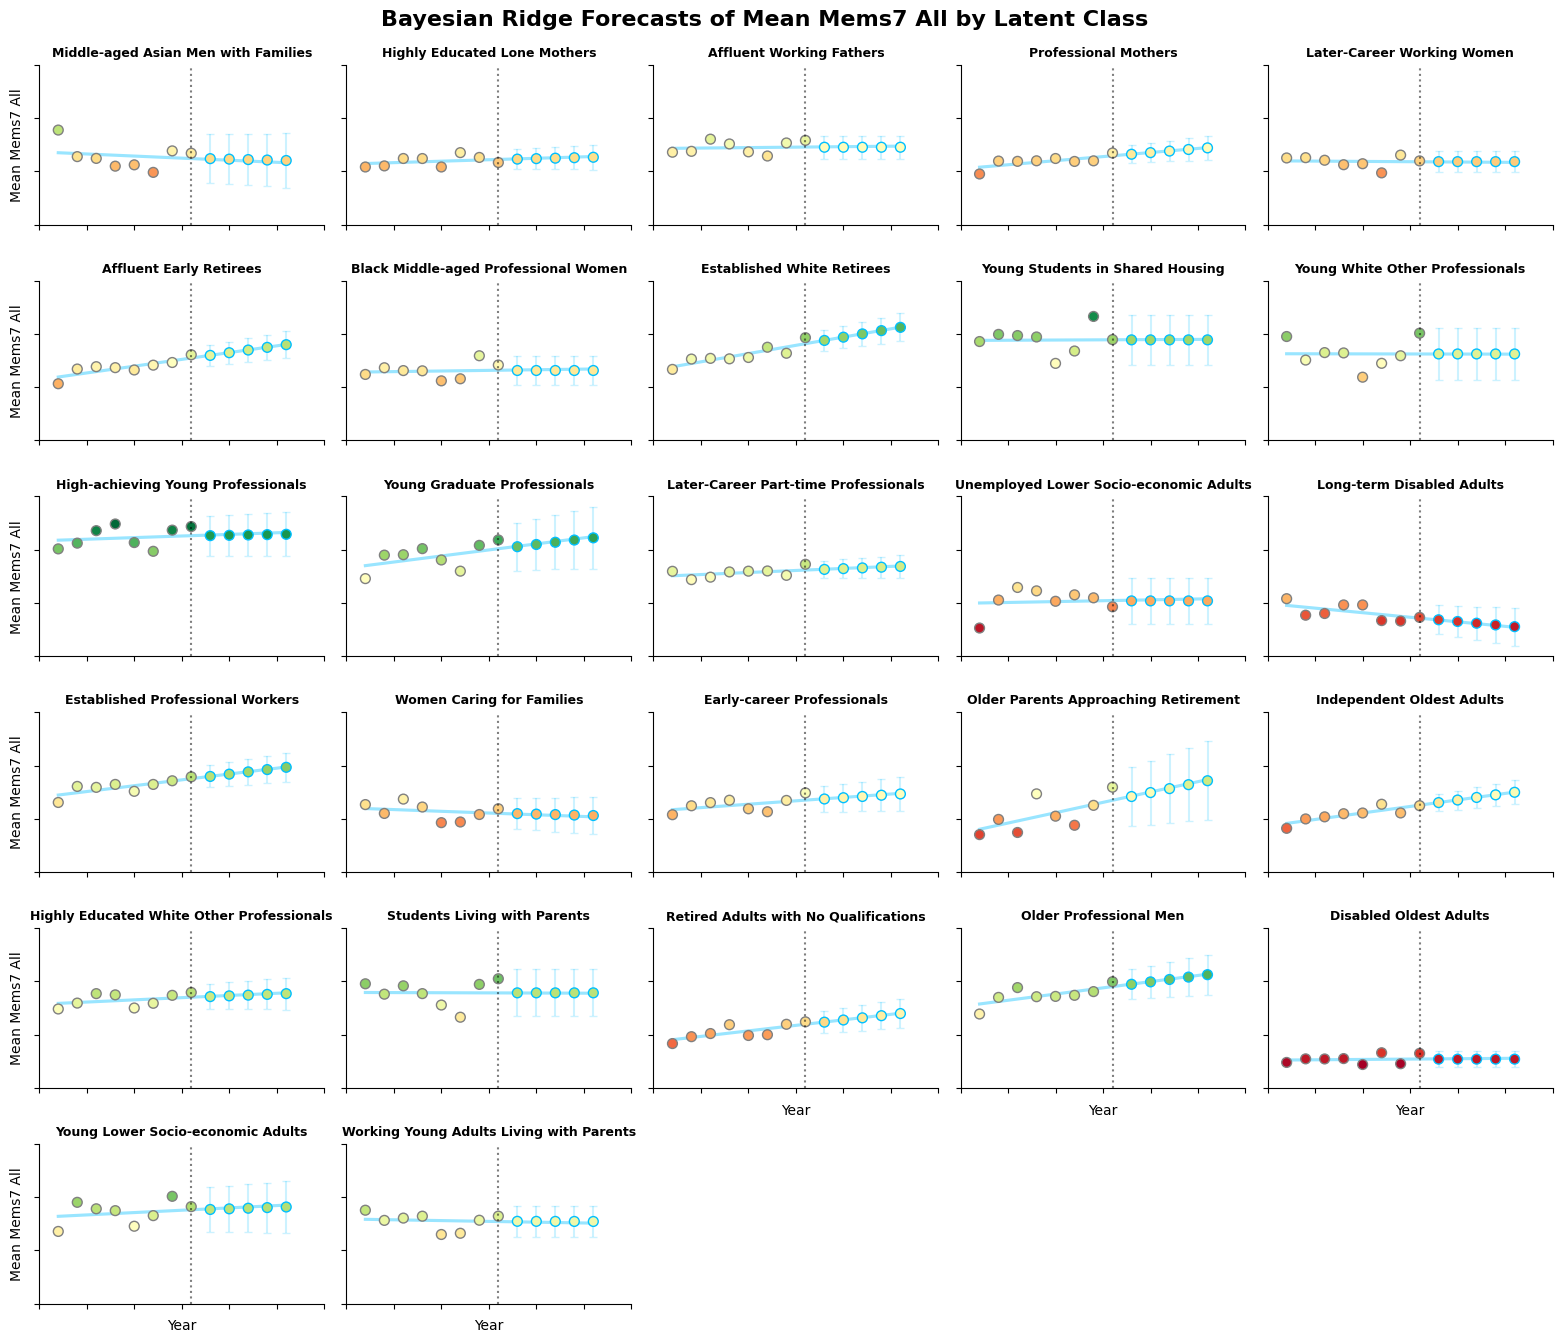

In [40]:
plot_df = forecast_df.copy()

plot_df["ClassName"] = plot_df["LCA_Class"].map(class_names)

plot_df["Forecast"] = plot_df["calendar_year"].isin(FORECAST_YEARS)

colours = (["#808080"] * len(INCLUDED_YEARS) + ["#00BFFF"] * len(FORECAST_YEARS))

g = sns.relplot(kind="scatter",
                data=plot_df,
                x="calendar_year",
                y="value",
                col="ClassName",
                col_wrap=5,
                height=2.3,
                aspect=1.4,
                s=50,
                palette="RdYlGn",
                hue="value",
                legend=False,
                edgecolors=colours,
                linewidth=1,
                zorder=2)

for cls_name, ax in g.axes_dict.items():

    class_df = (plot_df[plot_df["ClassName"] == cls_name].sort_values("calendar_year"))

    sns.regplot(data=class_df,
                x="calendar_year",
                y="value",
                scatter=False,
                ci=None,
                color="#00BFFF",
                line_kws={"alpha":0.4, "zorder":0},
                ax=ax)

    future = class_df[class_df["calendar_year"].isin(FORECAST_YEARS)]

    ax.errorbar(x=future["calendar_year"],
                y=future["value"],
                yerr=1.96*future["error"],
                fmt="none",
                color="#00BFFF",
                alpha=0.2,
                capsize=3,
                zorder=1)

    ax.axvline(INCLUDED_YEARS[-1], linestyle=":", color="black", alpha=0.5)

g.set_titles("{col_name}", weight="bold", size=9)

g.set(xlabel="Year", ylabel=target_col.replace("_", " ").title())

g.set_xticklabels([])
g.set_yticklabels([])

plt.subplots_adjust(top=0.94)

g.figure.suptitle(f"Bayesian Ridge Forecasts of {target_col.replace("_", " ").title()} by Latent Class", fontsize=16, fontweight="bold")

# plt.savefig(f"lca_{target_col.lower()}_bayesian_forecast.png", dpi=300, bbox_inches="tight")

plt.show()